# Train a MLP classifier on the CellXGene V2 training set we extracted

We built a training and test set in another notebook.  Now we train an MLP classifier

In [2]:
%run notebook_setup.ipynb

autoreload enabled
repo_dir set to /root/GenePT-tools
File already exists at /root/GenePT-tools/data/GenePT_emebdding_v2.zip
Extracting files...
Extracting GenePT_emebdding_v2/
Skipping GenePT_emebdding_v2/NCBI_UniProt_summary_of_genes.json - already exists with same size
Skipping GenePT_emebdding_v2/GenePT_gene_embedding_ada_text.pickle - already exists with same size
Skipping GenePT_emebdding_v2/GenePT_gene_protein_embedding_model_3_text.pickle. - already exists with same size
Skipping GenePT_emebdding_v2/NCBI_summary_of_genes.json - already exists with same size
Extraction complete!
Skipping embedding_original_ada_text.parquet - already exists
Skipping embedding_original_large_3.parquet - already exists
Skipping embedding_associations_age_cell_type_drugs_pathways_openai_large.parquet - already exists
Skipping embedding_associations_age_drugs_pathways_openai_large.parquet - already exists
Skipping embedding_associations_cell_type_openai_large.parquet - already exists
Skipping embeddi

In [3]:
import numpy as np
import pandas as pd
from sklearn.metrics import log_loss, f1_score, precision_score, recall_score
import wandb

## Load the data set

In [4]:
human_only_x10_cell_counts_pdf = pd.read_parquet(data_dir / "cellxgene" / "human_only_x10_cell_counts.parquet")
cell_types = list(human_only_x10_cell_counts_pdf.columns)

In [5]:
full_count_codes = human_only_x10_cell_counts_pdf.columns[human_only_x10_cell_counts_pdf.sum() > 10000].to_series().astype(
    pd.CategoricalDtype(categories=cell_types)
  ).cat.codes
full_count_codes_pdf = full_count_codes.reset_index().rename(columns={"index": "cell_type", 0: "code"})


def y_to_code(y):
  y.name = 'cell_type_code'
  return pd.merge(
    y,
    full_count_codes_pdf.reset_index(),
    left_on="cell_type_code",
    right_on="code",
    how="left"
  )['index']

def code_to_y(code):
  return full_count_codes_pdf.loc[code]['code']

def code_to_cell_type(code):
  return full_count_codes_pdf.loc[code]['cell_type']

In [6]:
len(full_count_codes)

377

In [7]:
import pandas as pd

def load_embedding(file_path):
  embedding_pdf = pd.read_parquet(file_path)
  columns_type_map = {
    "embedding": [col for col in embedding_pdf.columns if col.isdigit()],
    "metadata": [col for col in embedding_pdf.columns if not col.isdigit()],
  }
  X = embedding_pdf[columns_type_map['embedding']].to_numpy()
  y = embedding_pdf["cell_type"].astype(
    pd.CategoricalDtype(categories=cell_types)
  ).cat.codes

  return X, y
    


In [8]:
full_count_codes_pdf = full_count_codes.reset_index().rename(columns={"index": "cell_type", 0: "code"})
full_count_codes_pdf.head()

,cell_type,code
0,neuron,0
1,L2/3-6 intratelencephalic projecting glutamate...,1
2,oligodendrocyte,2
3,fibroblast,3
4,unknown,4


# Double buffered version

We ended up not using this in the final version because it results in training instability. This is because the files that delineate batches have different distributions, so each new patch causes a significant loss spike.  In order for this to work, we need to randomize the training set before training.

In [10]:


import threading
import torch
from torch.utils.data import IterableDataset
import pandas as pd
import numpy as np
from pathlib import Path
import random

class ParquetBatchDataset(IterableDataset):
  def __init__(self, parquet_dir, cell_types, cell_type_codes,
               n_dims=1500, batch_size=1024, min_rows=500_000, shuffle_files=True):
    super().__init__()
    self.files = list(Path(parquet_dir).glob("*.parquet"))
    self.cell_types = cell_types
    self.cell_type_codes = cell_type_codes
    self.n_dims = n_dims
    self.batch_size = batch_size
    self.min_rows = min_rows
    self.shuffle_files = shuffle_files

  def _load_chunk(self, files, start_idx):
    """Load files until min_rows is reached, then split into batches."""
    idx = start_idx
    dfs = []
    total_rows = 0
    n_files = len(files)
    columns = [str(i) for i in range(self.n_dims)] + ["cell_type"]

    while idx < n_files and total_rows < self.min_rows:
      df = pd.read_parquet(files[idx], columns=columns)
      df['cell_type'] = df['cell_type'].astype(
        pd.CategoricalDtype(categories=self.cell_types)
      )
      df = df[df['cell_type'].cat.codes.isin(self.cell_type_codes)]
      if len(df) > 0:
        dfs.append(df)
        total_rows += len(df)
      idx += 1

    if not dfs:
      return [], idx

    big_df = pd.concat(dfs, ignore_index=True)
    embedding_cols = [str(i) for i in range(self.n_dims)]
    X = big_df[embedding_cols].astype(np.float32).values
    y = y_to_code(big_df['cell_type'].cat.codes).values

    # shuffle
    perm = np.random.permutation(len(X))
    X = X[perm]
    y = y[perm]

    # split into tensor batches
    batches = []
    for i in range(0, len(X), self.batch_size):
      xb = torch.from_numpy(X[i:i + self.batch_size])
      yb = torch.from_numpy(y[i:i + self.batch_size])
      batches.append((xb, yb))

    return batches, idx

  def __iter__(self):
    files = self.files.copy()
    if self.shuffle_files:
      random.shuffle(files)

    file_idx = 0
    # load first chunk synchronously
    current_batches, file_idx = self._load_chunk(files, file_idx)

    # prepare next chunk in background
    next_queue = {}
    loader = None
    if file_idx < len(files):
      def _worker(start):
        next_queue['result'] = self._load_chunk(files, start)
      loader = threading.Thread(target=_worker, args=(file_idx,), daemon=True)
      loader.start()

    # double-buffered yielding
    while current_batches:
      for batch in current_batches:
        yield batch

      if loader:
        loader.join()
        current_batches, file_idx = next_queue['result']
        loader = None

        # kick off loading of the following chunk
        if file_idx < len(files):
          next_queue = {}
          loader = threading.Thread(
            target=_worker, args=(file_idx,), daemon=True
          )
          loader.start()
      else:
        break


# Full batch dataset

To get a first model built, we just load the entire data set into memory, with a reduced sized embedding.  This is a punt since we probably could have done this with XGBoost too, but it is a step towards out of memory and distributed training of larger models, so its ok.  We should, however, benchmark against XGBoost performance

In [11]:
import torch
from torch.utils.data import IterableDataset
import pandas as pd
import numpy as np
from pathlib import Path

class ParquetFullBatchDataset(IterableDataset):
  def __init__(self, parquet_dir, cell_types, cell_type_codes, n_dims=1500, batch_size=1024):
    super().__init__()
    self.files = list(Path(parquet_dir).glob("*.parquet"))
    self.cell_types = cell_types
    self.cell_type_codes = cell_type_codes
    self.n_dims = n_dims
    self.batch_size = batch_size

    dfs = []
    columns = [ str(i) for i in range(self.n_dims) ] + ["cell_type"]
    for file in self.files:
      df = pd.read_parquet(file, columns=columns)
      df['cell_type'] = df['cell_type'].astype(
        pd.CategoricalDtype(categories=self.cell_types)
      )
      df = df[df['cell_type'].cat.codes.isin(self.cell_type_codes)]
      if len(df) > 0:
        dfs.append(df)
    if not dfs:
      raise ValueError("No data found for the specified cell types.")

    big_df = pd.concat(dfs, ignore_index=True)
    embedding_cols = [str(i) for i in range(self.n_dims)]
    self.X = big_df[embedding_cols].astype(np.float32).values
    self.y = y_to_code(big_df['cell_type'].cat.codes).values
    self.n = len(self.X)

  def __iter__(self):
    # Shuffle at the start of each epoch
    indices = np.random.permutation(self.n)
    X_shuffled = self.X[indices]
    y_shuffled = self.y[indices]
    for i in range(0, self.n, self.batch_size):
      xb = torch.from_numpy(X_shuffled[i:i+self.batch_size])
      yb = torch.from_numpy(y_shuffled[i:i+self.batch_size])
      yield xb, yb

## Load the test set

In [14]:
from src.embeddings import load_data_set

val_120k_pdf = load_data_set(data_dir / "cellxgene_embeddings" / "test_v1", "cell_type")

def get_X_y(pdf):
  embedding_cols = [col for col in pdf.columns if col.isdigit()]
  y = pdf["cell_type"].astype(pd.CategoricalDtype(categories=cell_types)).cat.codes
  full_count_indexer = y.isin(full_count_codes_pdf.code)
  X = pdf[full_count_indexer][embedding_cols].to_numpy()
  y = y_to_code(y[full_count_indexer])
  return X, y

X_val_120k, y_val_120k = get_X_y(val_120k_pdf)

### Create a balanced subset of the test set for monitoring

We will run this check more often to monitor training dynamics

In [15]:
import numpy as np
import pandas as pd

# Assume val_120k_pdf is already loaded and cell_types is defined

n_total = 5000
cell_type_counts = val_120k_pdf['cell_type'].value_counts()
n_types = len(cell_type_counts)
max_per_type = n_total // n_types

# First, sample up to max_per_type from each cell type
balanced_samples = (
  val_120k_pdf.groupby('cell_type', group_keys=False)
  .apply(lambda x: x.sample(min(len(x), max_per_type), random_state=42))
)

# If we have less than 5k (because some cell types have fewer than max_per_type), fill up to 5k
remaining = n_total - len(balanced_samples)
if remaining > 0:
  # Get the leftover indices (not already in balanced_samples)
  leftover = val_120k_pdf.drop(balanced_samples.index)
  # Sample the rest randomly
  extra_samples = leftover.sample(remaining, random_state=42)
  balanced_samples = pd.concat([balanced_samples, extra_samples])

# Shuffle the final set
val_5k_pdf = balanced_samples.sample(frac=1, random_state=42).reset_index(drop=True)

# Now get X, y as before
X_val_5k, y_val_5k = get_X_y(val_5k_pdf)

/tmp/ipykernel_257687/1369173506.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), max_per_type), random_state=42))


## Set up Weights and Biases


In [16]:
import wandb
wandb.login(key="")
# wandb.init(project="cellxgene-xgboost-v1", config={"tree_method": "hist"})

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: honicky to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Use Optuna to tune hyperparmaeters 

This sometimes results in significant increases in performance, so its worthwhile to do one or two epochs of training on a small model like this

In [18]:
import optuna
import wandb
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import log_loss, f1_score, precision_score, recall_score

# Assume model, loss_fn, optimizer are defined
input_dim = 500  # or whatever your embedding size is
num_classes = len(full_count_codes_pdf)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_fn = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=1e-3)

parquet_dir = data_dir / "cellxgene_embeddings" / "training_v1"

def create_mlp(input_dim, num_classes, n_hidden_layers, dropout):
  layers = []
  dims = [int(input_dim + (num_classes - input_dim) * (i + 1) / (n_hidden_layers + 1)) for i in range(n_hidden_layers)]
  prev_dim = input_dim
  for h_dim in dims:
    layers.append(nn.Linear(prev_dim, h_dim))
    layers.append(nn.BatchNorm1d(h_dim))
    layers.append(nn.ReLU())
    layers.append(nn.Dropout(dropout))
    prev_dim = h_dim
  layers.append(nn.Linear(prev_dim, num_classes))
  return nn.Sequential(*layers)

def mrr_at_k(y_true, y_pred_probs, k):
  topk_preds = np.argsort(y_pred_probs, axis=1)[:, -k:][:, ::-1]
  rr = []
  for i in range(len(y_true)):
    if y_true[i] in topk_preds[i]:
      rank = np.where(topk_preds[i] == y_true[i])[0][0]
      rr.append(1.0 / (rank + 1))
    else:
      rr.append(0.0)
  return np.mean(rr)

def dcg_at_k(y_true, y_pred_probs, k):
  topk_preds = np.argsort(y_pred_probs, axis=1)[:, -k:][:, ::-1]
  dcg = []
  for i in range(len(y_true)):
    if y_true[i] in topk_preds[i]:
      rank = np.where(topk_preds[i] == y_true[i])[0][0]
      dcg.append(1.0 / np.log2(rank + 2))
    else:
      dcg.append(0.0)
  return np.mean(dcg)

def recall_at_k(y_true, y_pred_probs, k):
  topk_preds = np.argsort(y_pred_probs, axis=1)[:, -k:][:, ::-1]
  hits = [y_true[i] in topk_preds[i] for i in range(len(y_true))]
  return np.mean(hits)

def evaluate(model, X, y, batch_size=1024):
  y = np.asarray(y)
  model.eval()
  all_preds = []
  with torch.no_grad():
    for i in range(0, len(X), batch_size):
      xb = torch.tensor(X[i:i+batch_size], dtype=torch.float32).to(device)
      logits = model(xb)
      preds = torch.softmax(logits, dim=1).cpu().numpy()
      all_preds.append(preds)
  all_preds = np.concatenate(all_preds, axis=0)
  y_pred = all_preds.argmax(axis=1)
  logloss = log_loss(y, all_preds, labels=np.arange(num_classes))
  macro_f1 = f1_score(y, y_pred, average='macro', labels=np.arange(num_classes))
  macro_precision = precision_score(y, y_pred, average='macro', labels=np.arange(num_classes), zero_division=0)
  macro_recall = recall_score(y, y_pred, average='macro', labels=np.arange(num_classes), zero_division=0)

  metrics = {
    "logloss": logloss,
    "macro_f1": macro_f1,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall
  }

  for k in [2, 5, 10]:
    metrics[f"recall_at_{k}"] = recall_at_k(y, all_preds, k)
    metrics[f"mrr_at_{k}"] = mrr_at_k(y, all_preds, k)
    metrics[f"dcg_at_{k}"] = dcg_at_k(y, all_preds, k)

  return metrics, y, all_preds, y_pred


def objective(trial, input_dim=input_dim, dataset=None):
  # Suggest hyperparameters
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
  dropout = trial.suggest_uniform('dropout', 0.0, 0.5)
  n_hidden_layers = trial.suggest_int('n_hidden_layers', 1, 4)
  batch_size = trial.suggest_categorical('batch_size', [1024, 2048, 4096])
  return train_mlp(input_dim, num_classes, n_hidden_layers, dropout, learning_rate, batch_size, epochs=2, trial=trial, dataset=dataset)


def initialize_mlp(input_dim, num_classes, n_hidden_layers, dropout, learning_rate, checkpoint_path=None):
  model = create_mlp(input_dim, num_classes, n_hidden_layers, dropout).to(device)
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)
  start_epoch = 0
  start_batch = 0
  if checkpoint_path is not None:
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_batch = checkpoint.get('n_batches', 0)
    start_epoch = checkpoint.get('epoch', 0)
  return model, optimizer, start_epoch, start_batch


def train_mlp_epoch(model, optimizer, dataloader, epochs, start_epoch=0, start_batch=0, trial=None, wandb_run=None):
  n_batches = start_batch
  best_val5k_logloss = float('inf')
  for epoch in range(start_epoch, epochs):
    if wandb_run:
      wandb.log({ "epoch": epoch }, step=n_batches)
    for X_batch, y_batch in tqdm(dataloader):
      model.train()
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device).long()
      optimizer.zero_grad()
      logits = model(X_batch)
      loss = nn.CrossEntropyLoss()(logits, y_batch)
      loss.backward()
      optimizer.step()
      n_batches += 1
      if wandb_run:
        wandb.log({ "loss": loss.item() }, step=n_batches)
      if trial:
        trial.report(loss.item(), n_batches)
      if n_batches % 10 == 0:
        metrics_5k, _, _, _ = evaluate(model, X_val_5k[:, :model[0].in_features], y_val_5k)
        # print(f"[Batch {n_batches}] 5K Eval: {metrics_5k}")
        if wandb_run:
          wandb.log({f"val5k_{k}": v for k, v in metrics_5k.items()}, step=n_batches)
        best_val5k_logloss = min(best_val5k_logloss, metrics_5k["logloss"])
      if n_batches % 250 == 0:
        metrics_120k, _, _, _ = evaluate(model, X_val_120k[:, :model[0].in_features], y_val_120k)
        print(f"[Batch {n_batches}] 120K Eval: {metrics_120k}")
        if wandb_run:
          wandb.log({f"val120k_{k}": v for k, v in metrics_120k.items()}, step=n_batches)
      if n_batches % 1000 == 0:
        checkpoint = {
          'model_state_dict': model.state_dict(),
          'optimizer_state_dict': optimizer.state_dict(),
          'n_batches': n_batches,
          'epoch': epoch,
        }
        model_dir = repo_dir / "models" / wandb.run.id
        model_dir.mkdir(parents=True, exist_ok=True)
        torch.save(checkpoint, model_dir / f"mlp_checkpoint_{n_batches}.pt")
        if wandb_run:
          wandb.save(str(model_dir / f"mlp_checkpoint_{n_batches}.pt"))
        print(f"Checkpoint saved at batch {n_batches}")
  metrics_120k, y, _, y_pred  = evaluate(model, X_val_120k[:, :model[0].in_features], y_val_120k)
  wandb.log({
    "confusion_matrix": wandb.plot.confusion_matrix( 
      preds=y_pred,
      y_true=y,
      class_names=cell_types
    )
  })

  
  return metrics_120k["logloss"]


def train_mlp(input_dim, num_classes, n_hidden_layers, dropout, learning_rate, batch_size, epochs, trial=None, checkpoint_path=None, dataset = None):
  model, optimizer, start_epoch, start_batch = initialize_mlp(input_dim, num_classes, n_hidden_layers, dropout, learning_rate, checkpoint_path)
  if dataset is None: 
    dataset = ParquetBatchDataset(parquet_dir, cell_types, full_count_codes, n_dims=input_dim, batch_size=batch_size, min_rows=150_000)
  dataloader = DataLoader(dataset, batch_size=None)
  config = {
      "input_dim": input_dim,
      "num_classes": num_classes,
      "batch_size": batch_size,
      "learning_rate": learning_rate,
      "dropout": dropout,
      "n_hidden_layers": n_hidden_layers,
      "epochs": epochs,
      "device": device.type,
      "parquet_dir": str(parquet_dir),
      "cell_type_counts": len(cell_types),
    }
  if trial:
    config["optuna_trial"] = trial.number
  wandb_run = wandb.init(
    project="cellxgene-mlp-v1",
    config=config,
    reinit='finish_previous',
  )
  logloss = train_mlp_epoch(
    model, optimizer, dataloader, epochs,
    start_epoch=start_epoch,
    start_batch=start_batch,
    trial=trial,
    wandb_run=wandb_run
  )
  wandb_run.finish()
  return logloss



/root/GenePT-tools/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [53]:
full_dataset = ParquetFullBatchDataset(
    parquet_dir,
    cell_types,
    full_count_codes,
    n_dims=500,
    batch_size=1024
)

# Run the Optuna study

I deleted the output from the notebook because its huge, but the best outcome was this one:

**nwhis8xb**

In [ ]:
# Run Optuna study
study = optuna.create_study(direction="minimize")

study.optimize(lambda trial: objective(trial, dataset=full_dataset, input_dim=full_dataset.n_dims), n_trials=30)

print("Best trial:")
trial = study.best_trial
print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
  print(f"    {key}: {value}")

# Fetch our favorite run

In [25]:
import wandb

run_id = "nwhis8xb"

api = wandb.Api()
run = api.run(f"honicky/cellxgene-mlp-v1/{run_id}")
config = run.config

config


{'_wandb': {'value': {'cli_version': '0.19.11',
   'm': [],
   'python_version': '3.12.8',
   't': {'1': [1, 5, 35, 53, 55, 95, 105],
    '2': [1, 5, 35, 53, 55, 95, 105],
    '3': [2, 3, 16, 23, 55, 61],
    '4': '3.12.8',
    '5': '0.19.11',
    '8': [1, 5],
    '10': [20],
    '12': '0.19.11',
    '13': 'linux-x86_64'}}},
 'batch_size': {'value': 1024},
 'cell_type_counts': {'value': 738},
 'device': {'value': 'cuda'},
 'dropout': {'value': 0.042033229594233806},
 'epochs': {'value': 2},
 'input_dim': {'value': 1500},
 'learning_rate': {'value': 0.001316540565994942},
 'n_hidden_layers': {'value': 1},
 'num_classes': {'value': 738},
 'optuna_trial': {'value': 27},
 'parquet_dir': {'value': '/root/GenePT-tools/data/cellxgene_embeddings/training_v1'}}

# Run the best config for more epochs

It turns out that we did pretty well with just two epochs, so we can just use that one, but this is how we can train for more epochs if it makes sense

In [ ]:
# study.optimize(lambda trial: objective(trial, dataset=full_dataset, input_dim=500), n_trials=30)

# train_mlp(input_dim, num_classes, n_hidden_layers, dropout, learning_rate, batch_size, epochs=4, trial=None, dataset=full_dataset)
input_dim = 500
log_loss_120k = train_mlp(
  input_dim,
  num_classes,
  config['n_hidden_layers']['value'],
  config['dropout']['value'],
  config['learning_rate']['value'],
  config['batch_size']['value'],
  epochs=10,
  trial=None,
  dataset=full_dataset
)


In [ ]:
checkpoint_path = repo_dir / "notebooks/wandb/run-20250527_163736-ndj0zsnk/files/ndj0zsnk/mlp_checkpoint_31000.pt"

model, optimizer, start_epoch, start_batch = initialize_mlp(
  input_dim,
  num_classes,
  config['n_hidden_layers']['value'],
  config['dropout']['value'],
  config['learning_rate']['value'],
  checkpoint_path
)


In [33]:
dataset = ParquetBatchDataset(
  parquet_dir, cell_types, full_count_codes,
  n_dims=input_dim, batch_size=config['batch_size']['value'], min_rows=150_000
)
dataloader = DataLoader(dataset, batch_size=None)


In [ ]:

wandb_run = wandb.init(
  project="cellxgene-mlp-v1",
  config={
    "input_dim": input_dim,
    "num_classes": num_classes,
    "batch_size": config['batch_size']['value'],
    "learning_rate": config['learning_rate']['value'],
    "dropout": config['dropout']['value'],
    "n_hidden_layers": config['n_hidden_layers']['value'],
    "epochs": 10,
    "device": device.type,
    "parquet_dir": str(parquet_dir),
    "cell_type_counts": len(cell_types),
    "resumed_from_checkpoint": checkpoint_path,
  },
  reinit='finish_previous',
)

train_mlp_epoch(model, optimizer, dataloader, epochs=10, start_epoch=start_epoch, start_batch=start_batch, trial=None, wandb_run=wandb_run)

In [23]:
import yaml

run_base = repo_dir / "notebooks/wandb/run-20250528_064140-nwhis8xb"
config = yaml.safe_load(open(run_base / "files/config.yaml", "r"))
checkpoint_path = run_base / "files/nwhis8xb/mlp_checkpoint_6000.pt"

input_dim = 500
model, optimizer, start_epoch, start_batch = initialize_mlp(
  input_dim,
  num_classes,
  config['n_hidden_layers']['value'],
  config['dropout']['value'],
  config['learning_rate']['value'],
  checkpoint_path
)

/tmp/ipykernel_257687/2895737024.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


In [24]:
model = model.to(device)
model.eval()

metrics, y, all_preds, y_pred = evaluate(
  model, X_val_120k[:, :model[0].in_features], y_val_120k
)

/root/GenePT-tools/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
metrics

{'logloss': 2.1253606961723346,
 'macro_f1': np.float64(0.09175838079926997),
 'macro_precision': np.float64(0.10926936605826608),
 'macro_recall': np.float64(0.09239078614039656),
 'recall_at_2': np.float64(0.5612788950118085),
 'mrr_at_2': np.float64(0.4890726758749016),
 'dcg_at_2': np.float64(0.5079805608307453),
 'recall_at_5': np.float64(0.7633292778930795),
 'mrr_at_5': np.float64(0.5457974009399078),
 'dcg_at_5': np.float64(0.6000764211909492),
 'recall_at_10': np.float64(0.8701513633435912),
 'mrr_at_10': np.float64(0.560272809295478),
 'dcg_at_10': np.float64(0.6348413931152191)}

In [26]:
densities = np.zeros([all_preds.shape[1], all_preds.shape[1]], dtype=np.float32)

for i in range(all_preds.shape[0]):
  densities[y[i]] += all_preds[i]

for _, idx, count in pd.Series(y).value_counts().reset_index().itertuples():
  densities[idx] /= count



In [48]:
densities.shape

(377, 377)

In [27]:
non_zero_idx = np.where(np.sum(densities, axis=1) > 0)
non_zero_densities = densities[non_zero_idx[0], :][:, non_zero_idx[0]]

In [28]:
non_zero_densities_pdf = pd.DataFrame(non_zero_densities, index=code_to_cell_type(non_zero_idx).values, columns=code_to_cell_type(non_zero_idx).values)

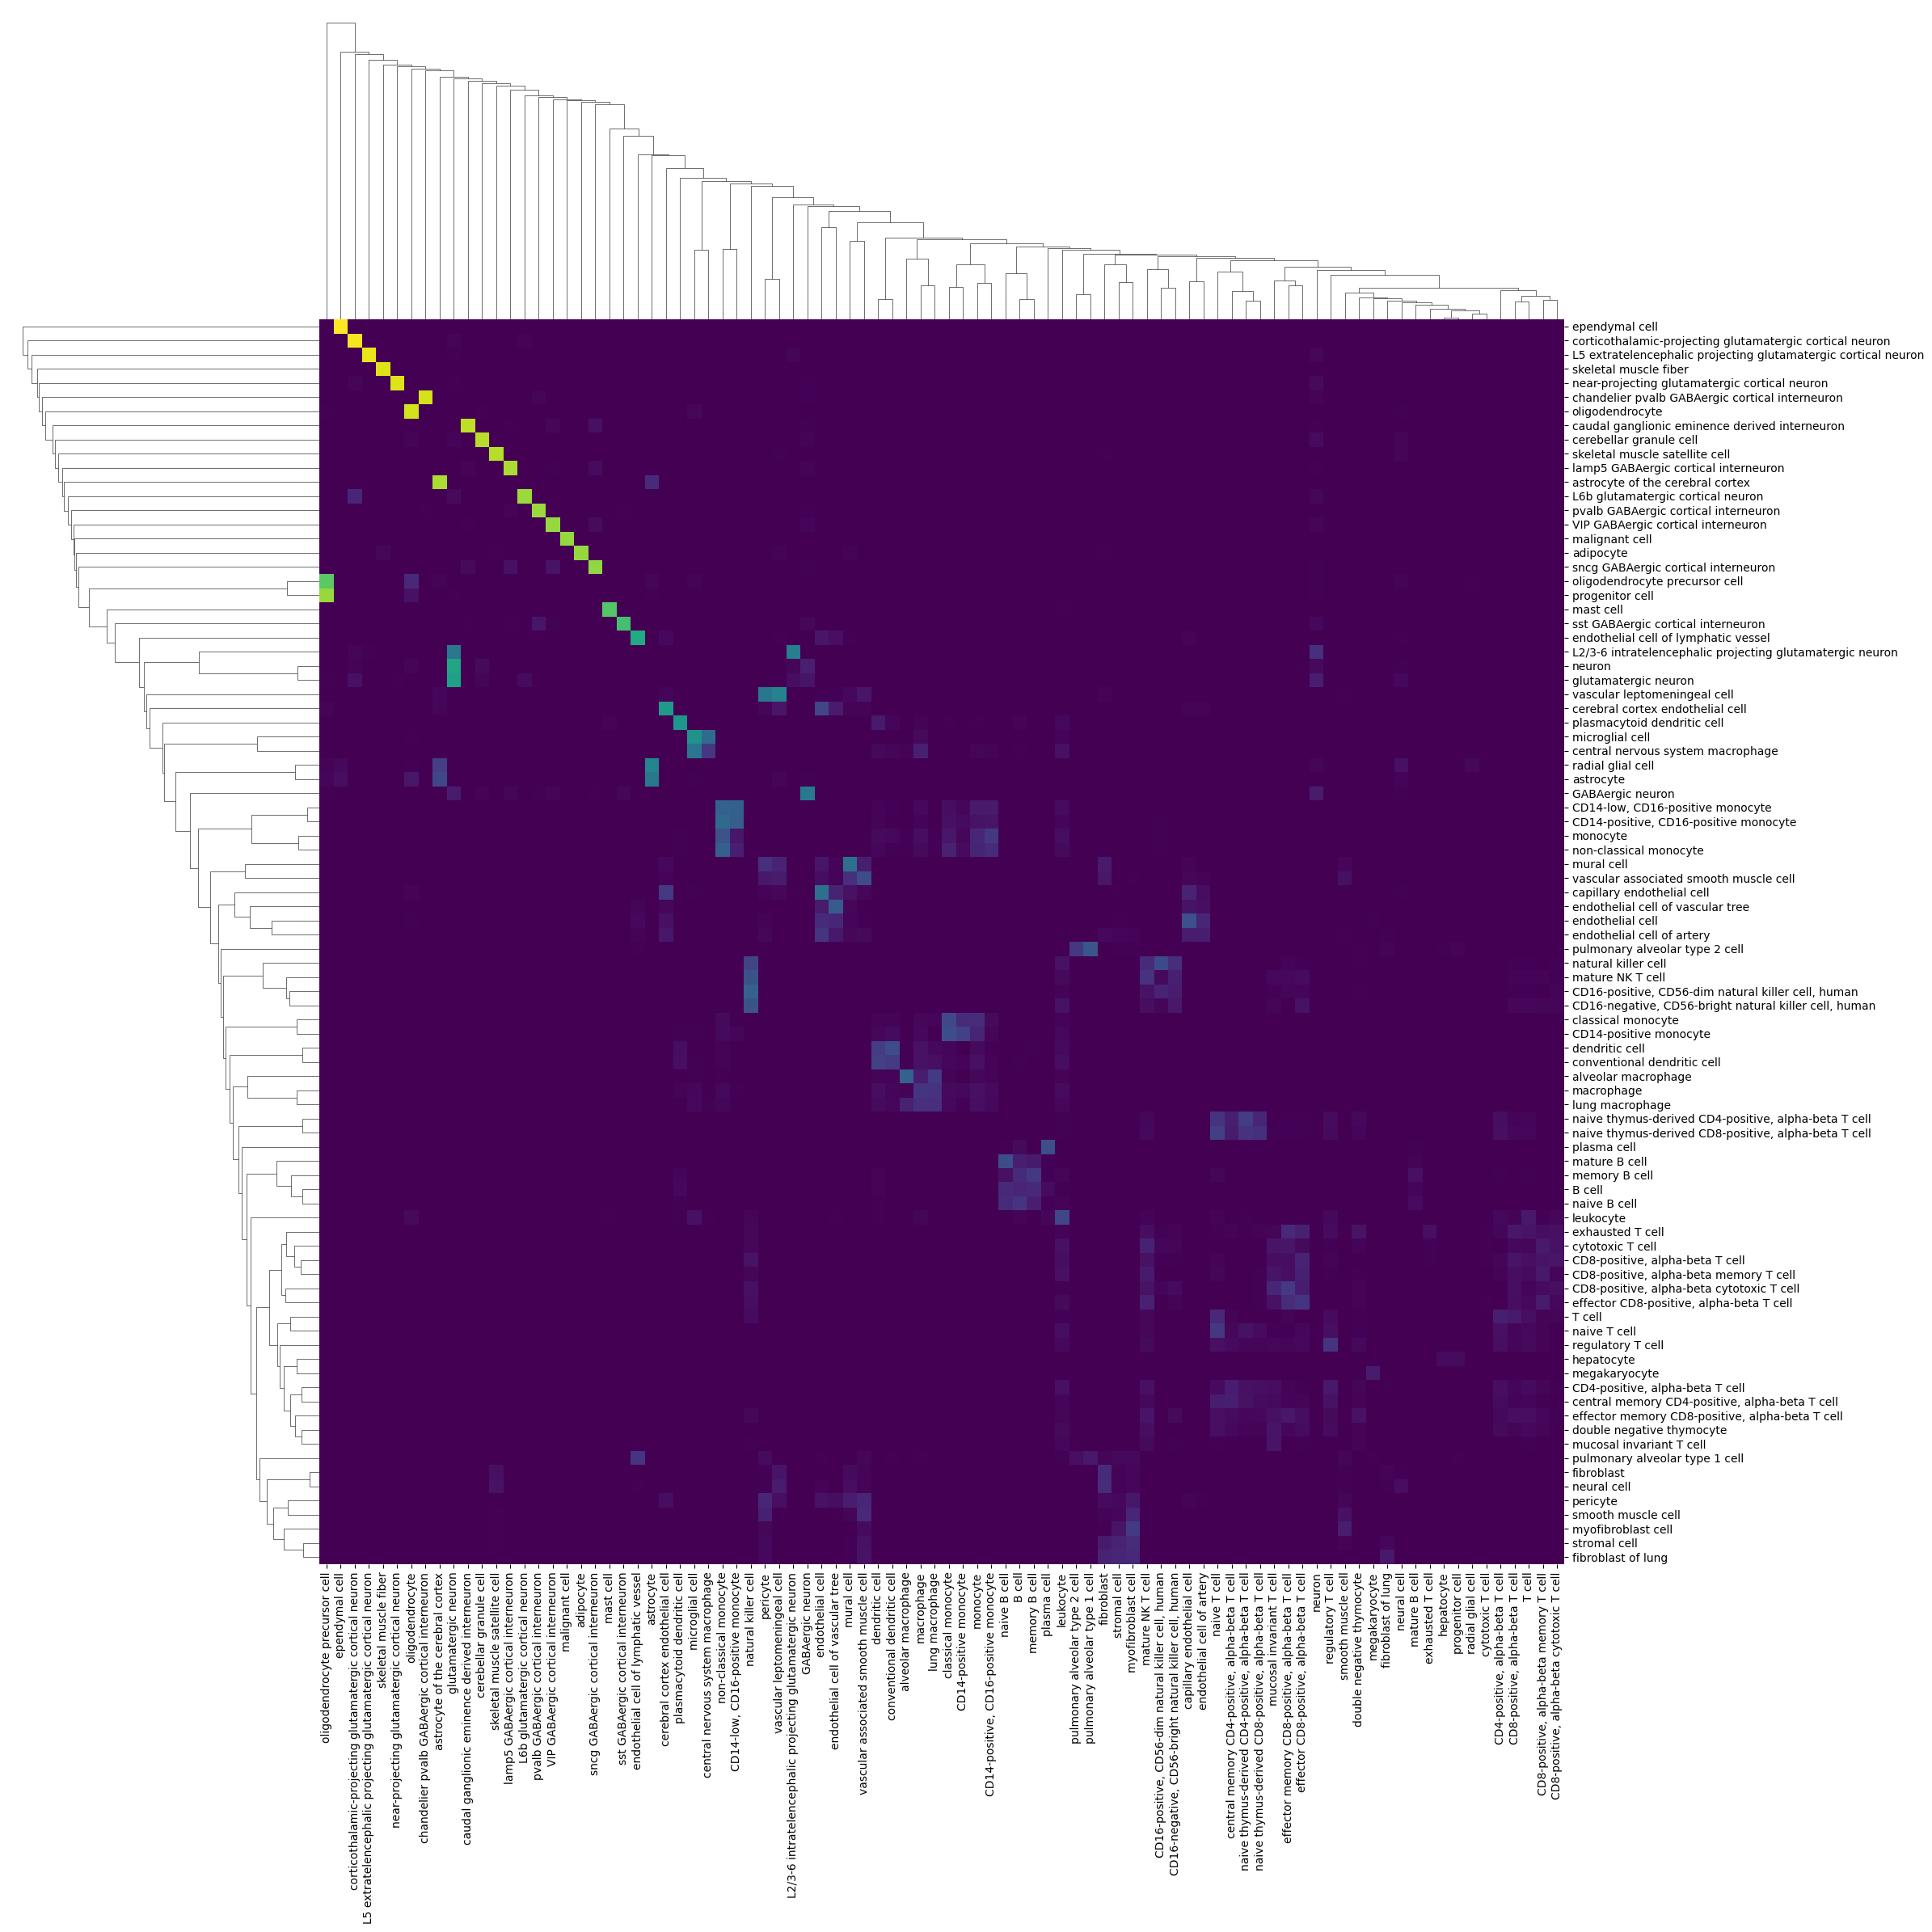

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.clustermap(
  non_zero_densities_pdf,
  figsize=(24, 24),
  cmap='viridis',
  cbar=False  # This should turn off the colorbar
)

# Explicitly remove colorbar axes if it still appears
for ax in g.fig.axes:
  if hasattr(ax, 'colorbar') or 'colorbar' in str(type(ax)).lower():
    ax.remove()
# Alternatively, remove by axes position (colorbar is usually the last one)
if len(g.fig.axes) > 2:
  g.fig.axes[-1].remove()

plt.show()

In [66]:
cell_type_labels.shape

(88,)

In [44]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list

# 1. Compute linkage for rows and columns
row_linkage = linkage(non_zero_densities_pdf, method='average')
col_linkage = linkage(non_zero_densities_pdf.T, method='average')

# 2. Get the order of rows and columns after clustering
row_order = leaves_list(row_linkage)
col_order = leaves_list(col_linkage)

# 3. Reorder the data and labels
data_clustered = non_zero_densities_pdf.values[row_order, :][:, col_order]
row_labels = code_to_cell_type(non_zero_idx).values[row_order]
col_labels = non_zero_densities_pdf.columns[col_order]

# 4. Create dendrogram traces
def create_dendro_traces(linkage_matrix, orientation, labels, xaxis, yaxis):
  dendro = dendrogram(linkage_matrix, labels=labels, orientation=orientation, no_plot=True)
  icoord = np.array(dendro['icoord'])
  dcoord = np.array(dendro['dcoord'])
  traces = []
  for xs, ys in zip(icoord, dcoord):
    if orientation == 'top':
      traces.append(go.Scatter(x=xs, y=ys, mode='lines', line=dict(color='black'), showlegend=False, xaxis=xaxis, yaxis=yaxis))
    else:
      traces.append(go.Scatter(x=ys, y=xs, mode='lines', line=dict(color='black'), showlegend=False, xaxis=xaxis, yaxis=yaxis))
  return traces

row_dendro_traces = create_dendro_traces(row_linkage, 'left', row_labels, 'x2', 'y2')
col_dendro_traces = create_dendro_traces(col_linkage, 'top', col_labels, 'x3', 'y3')


# Add heatmap, but hide colorbar
heatmap = go.Heatmap(
  z=data_clustered,
  x=col_labels,
  y=row_labels,
  # colorscale='Viridis',
  showscale=False,  # Hide the colorbar
  colorscale=[
        [0, 'rgb(0, 0, 0)'],              #0 - now black
        # [1./10000, 'rgb(50, 50, 50)'],   #10 - dark gray
        # [1./1000, 'rgb(100, 100, 100)'], #100 - medium gray
        # [1./100, 'rgb(150, 150, 150)'],  #1000 - light gray
        [1./10, 'rgb(50, 50, 50)'],   #10000 - lighter gray
        [1., 'rgb(250, 250, 250)'],      #100000 - now white
    ]
)

fig = go.Figure(data=[heatmap])
# Tidy up axes and labels
# Force all labels to show with minimal font size and no margins
fig.update_yaxes(
  tickfont=dict(size=9),  # Very small font size
  tickmode='linear',      # Force linear tick mode
  dtick=1,               # Show every tick (every row)
  ticklabeloverflow='allow'  # Allow labels to overflow/overlap
)

fig.update_xaxes(
  tickfont=dict(size=9),  # Very small font size
  tickmode='linear',      # Force linear tick mode
  dtick=1,               # Show every tick (every row)
  ticklabeloverflow='allow'  # Allow labels to overflow/overlap
)

fig.update_layout(
  showlegend=False,
  height=1200, width=1200,
  margin=dict(t=5, l=5, b=5, r=5),  # Remove all margins
  autosize=False
)
fig.show()

In [45]:
fig.write_html(repo_dir / "img/confusion_heatmap_log.html")